In [ ]:
import pandas as pd

In [2]:
data = pd.read_csv("logistic regression dataset-Social_Network_Ads.csv")

# Encode Gender
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

X = data[["Gender", "Age", "EstimatedSalary"]]
y = data["Purchased"]

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.40999396 0.31979185]


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_pca, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


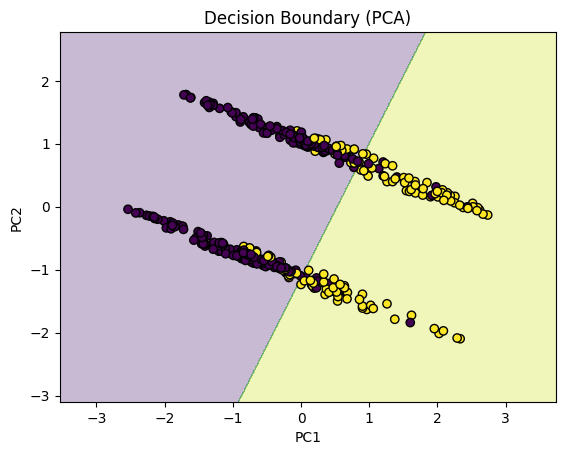

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary (PCA)")
plt.show()

In [7]:
####prediction
new_point = [[1, 30, 60000]]  
# Format: [Gender, Age, Salary]
# Gender: Male=0, Female=1 

In [8]:
# Scale using SAME scaler
new_scaled = scaler.transform(new_point)

# Apply SAME PCA
new_pca = pca.transform(new_scaled)

c:\Users\Rishabh Gupta\miniconda3\envs\new_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
pred = model.predict(new_pca)
prob = model.predict_proba(new_pca)

print("Predicted class:", pred[0])
print("Probability:", prob[0])

Predicted class: 0
Probability: [0.9371944 0.0628056]


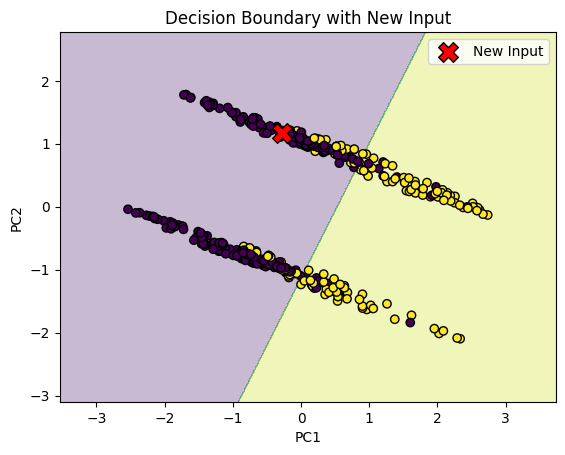

In [10]:
# Plot decision boundary (already done before)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k')

# 👉 Add new point
plt.scatter(
    new_pca[0, 0],
    new_pca[0, 1],
    color='red',
    s=200,
    edgecolors='black',
    marker='X',
    label='New Input'
)

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary with New Input")
plt.show()